# UA1 – Bloc 1 (Analyse des avis) – Notebook complet 

Ce notebook couvre tout le **Bloc 1** :  
**CSV → EDA → nettoyage → NLP (spaCy) → TF‑IDF → Topics (NMF) → Sentiment (baseline) → Exports**.

**Fichiers produits :**
- `ua1_reviews_enriched.csv` : avis + features (sentiment, topic)
- `ua1_topic_summary.csv` : résumé des topics (mots clés + exemples)


In [ ]:
%pip install -q pandas numpy scikit-learn matplotlib wordcloud vaderSentiment spacy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Cellule 2 — Imports + settings

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42


## 1) Chargement des données

On charge le CSV et on s’assure d’avoir une colonne `text`.


In [4]:
# Cellule 4 — Charger le CSV (tolérant)

path = "all_comments_ottawa.csv"
df = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")

if "text" not in df.columns:
    df = df.rename(columns={df.columns[0]: "text"})


df["text"] = df["text"].astype(str)
df = df[["text"]].copy()

df.head()

,text
0,Le spa propose un traitement signature exclusi...
1,Un séjour correct mais qui ne justifie pas ple...
2,The laundry service express saved our gala din...
3,L'exposition de collection d'art contemporain ...
4,L'emplacement privilégié est parfait pour expl...


In [5]:
# Cellule 5 — EDA rapide

print("Shape:", df.shape)
print("Valeurs vides:", df["text"].isna().sum())
print("Doublons:", df["text"].duplicated().sum())

df["len_chars"] = df["text"].str.len()
df["len_words"] = df["text"].str.split().apply(len)

df[["len_chars", "len_words"]].describe(percentiles=[.5, .75, .9, .95, .99])

Shape: (5945, 1)
Valeurs vides: 0
Doublons: 0


,len_chars,len_words
count,5945.000000,5945.000000
mean,773.279731,142.360303
std,736.585349,141.096960
min,38.000000,7.000000
50%,605.000000,112.000000
75%,1006.000000,186.000000
90%,1566.800000,291.000000
95%,2018.800000,379.800000
99%,3314.920000,624.680000
max,16975.000000,3505.000000


### Observation (EDA)

- Le dataset contient **5945 avis** (Shape: **(5945, 1)**).
- **Aucune valeur vide** et **aucun doublon** détecté à ce stade → base saine.
- Longueur des avis :
  - médiane ≈ **112 mots** (50%)
  - moyenne ≈ **142 mots**
  - présence de quelques avis très longs (jusqu’à **3505 mots**) → *longue traîne* normale (certains avis détaillés / copier-coller).
  
Implication : on peut faire du NLP + topic modeling sans correction majeure côté qualité brute, mais il faut garder en tête que les avis très longs peuvent influencer certains résultats.

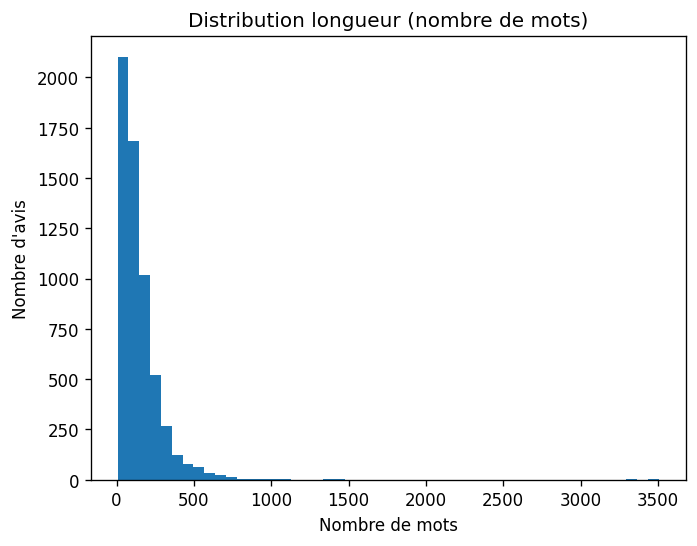

In [6]:
# Cellule 6 — Distribution de longueur (simple)

plt.figure()
plt.hist(df["len_words"], bins=50)
plt.title("Distribution longueur (nombre de mots)")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre d'avis")
plt.show()

## 2) Nettoyage (conserver heures / montants)

Ici on conserve :
- lettres + accents
- chiffres (ex: 15h00, 24h)
- symboles utiles: `$`, `%`, apostrophes

On met tout en minuscules et on normalise les espaces.


In [7]:
# Cellule 7 — Nettoyage

def clean_text(t: str) -> str:
    t = (t or "").lower()
    t = t.replace("\u00a0", " ")
    # garder lettres, chiffres, espaces, $ % et apostrophes
    t = re.sub(r"[^0-9a-zà-ÿ$%’'\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["clean"] = df["text"].apply(clean_text)

df[["text", "clean"]].head(5)

,text,clean
0,Le spa propose un traitement signature exclusi...,le spa propose un traitement signature exclusi...
1,Un séjour correct mais qui ne justifie pas ple...,un séjour correct mais qui ne justifie pas ple...
2,The laundry service express saved our gala din...,the laundry service express saved our gala din...
3,L'exposition de collection d'art contemporain ...,l'exposition de collection d'art contemporain ...
4,L'emplacement privilégié est parfait pour expl...,l'emplacement privilégié est parfait pour expl...


In [8]:
# Cellule 8 — Supprimer vides + doublons après nettoyage

before = len(df)
df = df[df["clean"].str.len() > 0].copy()
df = df.drop_duplicates(subset=["clean"]).copy()
after = len(df)

print(f"Avant: {before} | Après: {after} | Supprimés: {before-after}")

Avant: 5945 | Après: 5945 | Supprimés: 0


### Observation (Nettoyage)

- Le nettoyage conserve les éléments utiles comme **heures**, **montants** et **durées** (ex: *15h00*, *25$*, *24h*), ce qui est important dans un contexte hôtel/restauration.
- Après nettoyage, **aucun avis supprimé** (Avant=5945 → Après=5945).
  
Implication : le nettoyage est “safe” (pas destructif) et le dataset reste complet.


## 3) Pré-traitement NLP (spaCy FR)

- lemmatisation (forme de base)
- suppression stopwords FR + EN
- suppression tokens trop courts

> Si tu as une erreur `Can't find model 'fr_core_news_sm'`, installe-le dans la cellule 1.


In [23]:
# Cellule 9 — spaCy preprocessing

import spacy
from spacy.lang.fr.stop_words import STOP_WORDS as FR_STOP

# plus rapide, on désactive parser/ner
nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
nlp.max_length = 2_000_000

STOP = set(FR_STOP) | set(ENGLISH_STOP_WORDS)

# stopwords "domaine" (ajuste si tu veux)
DOMAIN_STOP = {
    "hotel", "hôtel", "room", "stay", "ottawa", "promenade", "chambre", "séjour", "service"
}
STOP |= DOMAIN_STOP

# bruit fréquent (anglais mal lemmatisé par modèle FR)
NOISE = {"thi", "wa", "wer", "ther", "lik", "ha", "im", "dont", "didnt"}
STOP |= NOISE

def spacy_preprocess(texts, batch_size=200):
    out = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = []
        for tok in doc:
            if tok.is_space or tok.is_punct:
                continue
            lemma = tok.lemma_.lower().strip()
            if not lemma or len(lemma) < 2:
                continue
            if lemma in STOP:
                continue
            # if tok.like_num:
            #     continue
            tokens.append(lemma)
        out.append(" ".join(tokens))
    return out

df["processed"] = spacy_preprocess(df["clean"].tolist())
df[["clean", "processed"]].head(5)

,clean,processed
0,le spa propose un traitement signature exclusi...,spa proposer traitement signatur exclusif déve...
1,un séjour correct mais qui ne justifie pas ple...,correct justifier pleinement classement lux pr...
2,the laundry service express saved our gala din...,laundry express saved gala dinner following mi...
3,l'exposition de collection d'art contemporain ...,exposition collection art contemporain présent...
4,l'emplacement privilégié est parfait pour expl...,emplacement privilégier parfaire explorer vill...


### Observation (Pré-traitement spaCy)

- On passe de `clean` (texte nettoyé) à `processed` (lemmes + stopwords retirés).
- Le résultat est cohérent :
  - En FR : les mots deviennent des lemmes (ex: *propose → proposer*).
  - En EN : les stopwords sautent et on garde l’essentiel (ex: *laundry, express, dinner...*).

Note importante :
- Le corpus est **bilingue** (FR + EN). Comme on utilise un modèle spaCy FR, certains mots anglais peuvent parfois produire des tokens “bruit” (ex: `thi`, `wa`, `ar`, etc.).
Solution : garder une petite liste **NOISE stopwords** 

## 4) N-grams (top mots / expressions)

On regarde les unigrams + bigrams pour comprendre ce qui ressort.


In [24]:
# Cellule 10 — Top n-grams

def top_ngrams(texts, ngram_range=(1,1), top_n=20, min_df=5):
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    top_idx = np.argsort(freqs)[::-1][:top_n]
    return pd.DataFrame({"ngram": vocab[top_idx], "count": freqs[top_idx]})

top_uni = top_ngrams(df["processed"], ngram_range=(1,1), top_n=25, min_df=5)
top_bi  = top_ngrams(df["processed"], ngram_range=(2,2), top_n=25, min_df=5)

top_uni.head(10), top_bi.head(10)

(      ngram  count
 0     staff   3064
 1   ottawer   2984
 2     great   2969
 3     night   2513
 4  location   2385
 5      good   2355
 6    stayed   2237
 7      just   2101
 8     boire   2057
 9     lobby   1798,
                 ngram  count
 0       byward market    954
 1      parliamer hill    710
 2        rideau canal    671
 3  parliamer building    471
 4      great location    426
 5        stayed night    395
 6    national gallery    383
 7         small boire    378
 8      staff friendly    366
 9    walking distance    364)

### Observation (N-grams)

- Les **unigrams** confirment les thèmes dominants : *staff*, *location*, *night*, etc.
- Les **bigrams** montrent des “signaux business” très clairs :
  - **Byward Market**, **Parliament Hill**, **Rideau Canal**, **National Gallery**…
  
Interprétation :
- Beaucoup d’avis parlent de la **localisation** et des **points d’intérêt** proches → c’est un thème central.
- Ça donne une piste actionnable : la communication marketing peut mettre l’accent sur l’accessibilité à pied, les attractions, et les quartiers.


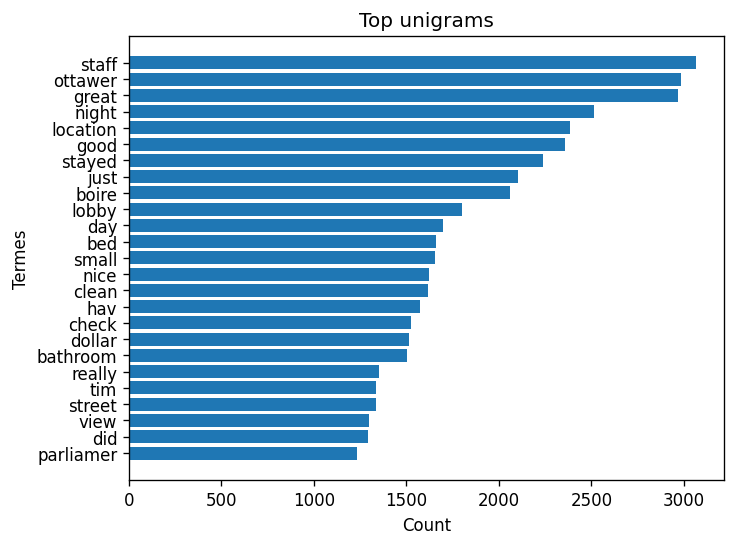

In [25]:
# Cellule 11 — Plot top unigrams

plt.figure()
plt.barh(top_uni.sort_values("count")["ngram"], top_uni.sort_values("count")["count"])
plt.title("Top unigrams")
plt.xlabel("Count")
plt.ylabel("Termes")
plt.show()

## 5) TF‑IDF + Topic Modeling (NMF)

On crée une matrice TF‑IDF puis on entraîne un NMF pour extraire des topics.


In [ ]:
# Cellule 12 — TF-IDF

tfidf = TfidfVectorizer(
    max_df=0.90,
    min_df=5,
    ngram_range=(1,2)
)
X = tfidf.fit_transform(df["processed"])
print("TF-IDF shape:", X.shape)

✅ TF-IDF shape: (5945, 12321)


### Observation (TF-IDF)

- La matrice TF-IDF a une forme **(5945, 12321)** :
  - 5945 documents (avis)
  - 12321 features (mots/expressions 1–2 grams filtrés)

Implication :
- Le vocabulaire est riche mais contrôlé (min_df, max_df).
- On a suffisamment de “signal” pour extraire des thèmes (topics) de manière stable.


In [ ]:
# Cellule 13 — NMF topics

n_topics = 8  # ajuste si tu veux 6-12
nmf = NMF(n_components=n_topics, random_state=RANDOM_STATE, init="nndsvda", max_iter=500)
W = nmf.fit_transform(X)
H = nmf.components_

df["topic"] = W.argmax(axis=1)
df["topic_score"] = W.max(axis=1)

print("Topics assignés:", df["topic"].nunique())
df[["text", "topic", "topic_score"]].head(5)

✅ Topics assignés: 8


,text,topic,topic_score
0,Le spa propose un traitement signature exclusi...,6,0.147780
1,Un séjour correct mais qui ne justifie pas ple...,6,0.035458
2,The laundry service express saved our gala din...,4,0.016274
3,L'exposition de collection d'art contemporain ...,2,0.014401
4,L'emplacement privilégié est parfait pour expl...,6,0.060890


In [28]:
# Cellule 14 — Mots-clés par topic

terms = np.array(tfidf.get_feature_names_out())

def topic_keywords(topic_id, top_n=12):
    row = H[topic_id]
    idx = np.argsort(row)[::-1][:top_n]
    return list(terms[idx])

topic_rows = []
for t in range(n_topics):
    topic_rows.append({
        "topic": t,
        "keywords": ", ".join(topic_keywords(t, top_n=12))
    })

topic_summary = pd.DataFrame(topic_rows)
topic_summary

,topic,keywords
0,0,"old, lobby, it, good, ar, nice, boire, really,..."
1,1,"market, byward, byward market, parliamer, hill..."
2,2,"bien, situer, bon, bien situer, vue, propre, p..."
3,3,"great, location, staff, great location, clean,..."
4,4,"dollar, check, night, day, told, did, got, des..."
5,5,"suite, ottawer, staff, wonderful, stayed, expe..."
6,6,"proposer, cuisine, gastronomique, proposer cui..."
7,7,"petit, déjeuner, petit déjeuner, produit, vari..."


In [29]:
# Cellule 15 — Exemples d'avis par topic (top score)

examples = []
for t in range(n_topics):
    sub = df[df["topic"] == t].sort_values("topic_score", ascending=False).head(3)
    for _, r in sub.iterrows():
        examples.append({
            "topic": t,
            "topic_score": float(r["topic_score"]),
            "text": r["text"][:250]
        })

examples_df = pd.DataFrame(examples)
examples_df.head(10)

,topic,topic_score,text
0,0,0.101010,Be booked at Hotel De La Promenade since this ...
1,0,0.099082,I stayed here on business and there is alot wr...
2,0,0.096448,Hotel De La Promenade is definitely one of the...
3,1,0.132828,"Next trip to Ottawa, back to Hotel De La Prome..."
4,1,0.123341,Excellent hotel - walking distance to the Parl...
5,1,0.106204,We have been to Hotel De La Promenade twice no...
6,2,0.186276,"Très bien situé, central de tout même à pied! ..."
7,2,0.175722,Nous avons eu la chance d'aller à Hotel De La ...
8,2,0.173704,"l'hôtel est très bien situé, juste à proximité..."
9,3,0.207420,"We had great views, lovely hotel, friendly sta..."


## 6) Sentiment (baseline)

On utilise VADER comme baseline (simple).  
**Note** : VADER est surtout optimisé anglais, donc c’est une baseline à interpréter avec prudence sur du FR.


In [30]:
# Cellule 16 — Sentiment VADER

analyzer = SentimentIntensityAnalyzer()

def sentiment_label(text: str) -> str:
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    return "neutral"

df["sentiment"] = df["clean"].apply(sentiment_label)
df["sentiment"].value_counts(normalize=True)

sentiment
positive    0.794954
neutral     0.115559
negative    0.089487
Name: proportion, dtype: float64

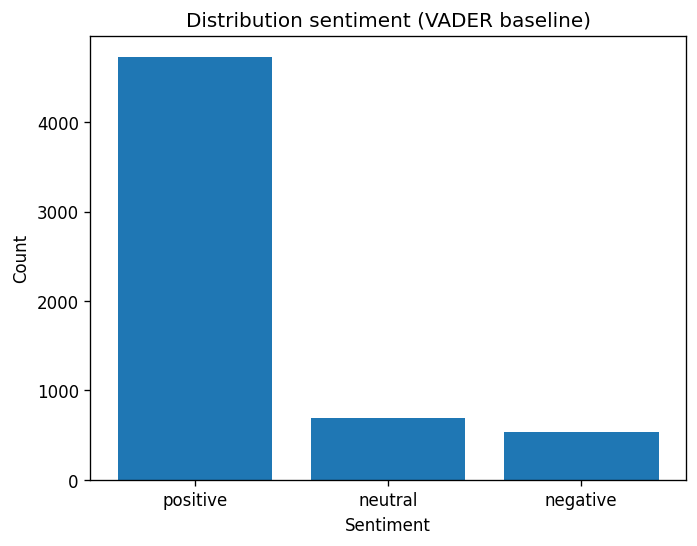

In [31]:
# Cellule 17 — Plot sentiment

counts = df["sentiment"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Distribution sentiment (VADER baseline)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### Observation (Sentiment baseline)

Répartition (VADER) :
- **Positive ~ 79.5%**
- **Neutral ~ 11.6%**
- **Negative ~ 8.9%**

Interprétation :
- La majorité des avis sont positifs (ce qui est fréquent pour des avis d’hôtel/restauration).
- Les avis négatifs restent significatifs : ils permettent d’identifier des irritants à croiser avec les topics (ex: facturation, réception, bruit, etc.).

Limite méthodologique :
- VADER est surtout optimisé pour l’anglais → sur les avis FR, c’est un **baseline** à interpréter avec prudence (mais acceptable pour UA1).


## 7) WordCloud (optionnel)

Si tu veux un visuel rapide.


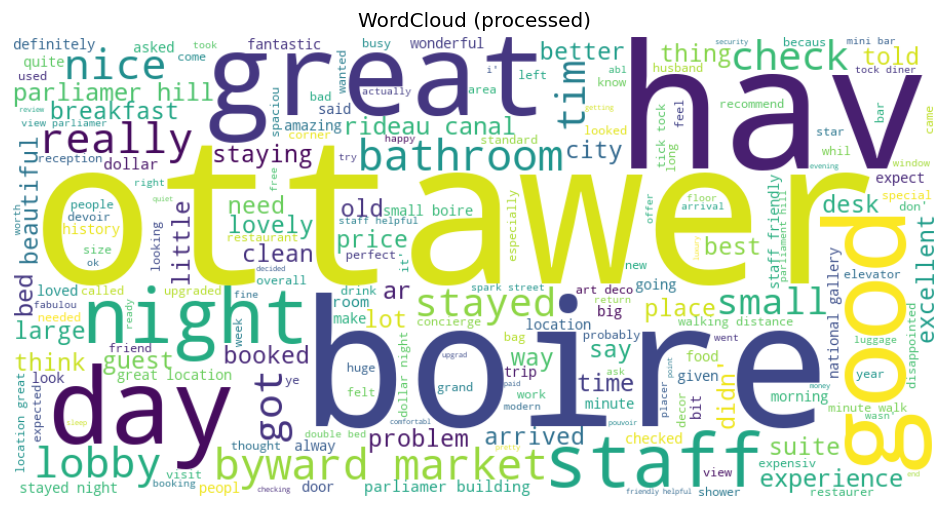

In [32]:
# Cellule 18 — WordCloud (optionnel)

from wordcloud import WordCloud

text_blob = " ".join(df["processed"].astype(str).tolist())

wc = WordCloud(width=900, height=450, background_color="white").generate(text_blob)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud (processed)")
plt.show()

## 8) Exports (fichiers de remise)

- `ua1_reviews_enriched.csv` (avis + sentiment + topic)
- `ua1_topic_summary.csv` (keywords + exemples)


In [33]:
# Cellule 19 — Construire un résumé de topics + exemples

# Ajouter 2 exemples par topic dans le summary
topic_to_examples = (
    df.sort_values("topic_score", ascending=False)
      .groupby("topic")["text"]
      .apply(lambda s: " || ".join(s.head(2).astype(str).str.slice(0,200)))
      .to_dict()
)

topic_summary["examples"] = topic_summary["topic"].map(topic_to_examples)

topic_summary

,topic,keywords,examples
0,0,"old, lobby, it, good, ar, nice, boire, really,...",Be booked at Hotel De La Promenade since this ...
1,1,"market, byward, byward market, parliamer, hill...","Next trip to Ottawa, back to Hotel De La Prome..."
2,2,"bien, situer, bon, bien situer, vue, propre, p...","Très bien situé, central de tout même à pied! ..."
3,3,"great, location, staff, great location, clean,...","We had great views, lovely hotel, friendly sta..."
4,4,"dollar, check, night, day, told, did, got, des...",Overall the hotel is clean. Our room seems to ...
5,5,"suite, ottawer, staff, wonderful, stayed, expe...",I booked the last two nights of an eight night...
6,6,"proposer, cuisine, gastronomique, proposer cui...",Restaurant proposant une cuisine de qualité ma...
7,7,"petit, déjeuner, petit déjeuner, produit, vari...",Le petit-déjeuner en chambre est servi avec un...


### Qualité des topics (validation rapide)

- Certains topics sont très “propres” et faciles à interpréter (ex : un topic avec **Byward Market / Parliament Hill** = localisation).
- Certains topics peuvent contenir un peu de bruit (ex: tokens anglais raccourcis comme `ar`, `it`, etc.) si le corpus est très mixte.

Conclusion :
- Le modèle de topics est exploitable pour produire un résumé directionnel (thèmes récurrents + exemples).
- Si un topic contient trop de bruit, on améliore simplement les stopwords (NOISE) et on relance TF-IDF + NMF.


In [ ]:
# Cellule 20 — Sauvegarder CSV
from pathlib import Path

out_reviews = Path("ua1_reviews_enriched.csv")
out_topics = Path("ua1_topic_summary.csv")

df_out = df.drop(columns=["len_chars", "len_words"], errors="ignore").copy()

df_out.to_csv(out_reviews, index=False, encoding="utf-8")
topic_summary.to_csv(out_topics, index=False, encoding="utf-8")

print("Export OK:")
print("-", out_reviews.resolve())
print("-", out_topics.resolve())

✅ Export OK:
- C:\Users\Administrator\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Intelligence Artificielle Générative\projet_UA1\ua1_reviews_enriched.csv
- C:\Users\Administrator\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Intelligence Artificielle Générative\projet_UA1\ua1_topic_summary.csv


###  Sorties finales (exports)

Deux fichiers sont produits pour la suite / remise :
- `ua1_reviews_enriched.csv` : avis + colonnes NLP (topic, topic_score, sentiment)
- `ua1_topic_summary.csv` : keywords + exemples par topic (résumé directionnel)

Implication :
- Le Bloc 1 est complet et “prêt” : on peut ensuite enchaîner vers le Bloc 2 (RAG) avec une base propre.
